# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**

**Dr Luis Eduardo Falcón Morales**

**Tecnológico de Monterrey**
### **Actividad Individual: Pronósticos con Series de Tiempo**


#### **Nombre: Kevin Rogelio Rodriguez Magaña**
#### **Matrícula: A1840418**

Modelos para predicción de un problema de serie de tiempo:

* **1. Modelo ingenuo**
* **2. Modelo ARIMA**
* **3. Modelo Prophet**
* **4. Modelo LSTM**


NOTA: Recuerda que cada modelo puede llegar a tener una gran cantidad de hiperparámetros y tipo de ajsutes, por lo que siempre inicia con un modelo sencillo y de ahí buscar mejorar su resultado. Esto para no desgastarte desde un inicio buscando la mayor cantidad de ajustes e hiperparámetros.

# **A - Introducción**

In [3]:
# Agrega aquí todas las librerías y paquetes adicionales que requieras.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


None



# **Ejercicio 1**

* **1a. De la página de Google-Trends generar y descargar los datos con períodos mensuales que se obtienen con el "Término de búsqueda" de "chocolate", del país "Estados Unidos", de los últimos 20 años (del 1 de mayo del 2006 al 30 de abril del 2026) y con las opciones de "todas las categorías" y "búsqueda de web". De manera predeterminada se generan datos mensuales.**

* **1b. Cargar los datos en un DataFrame de Pandas llamado "dfp" y con los nombres"ds" y "y" para las columnas de fechas y porcentajes de interés de búsqueda, respectivamente. Las fechas ajustarlas al formato YYYY-MM-DD, con días de fin de mes. Este formato es el que se requiere para el modelo Prophet.**

* **1c. A partir del DataFrame "dfp", genera ahora el DataFrame que llamaremos "dfr" para el resto de los modelos. El formato en "dfr" requerido para el resto de los modelos debe tener la primera columna de fechas de "dfp" ahora como índice del DataFrame "dfr". Además, el índice de fechas debe tener una frecuencia mensual al final del mes.**



https://trends.google.es/trends/



In [6]:


# Ejercicios 1a y 1b.

# ************* Inlcuye aquí tu código:*****************************

file = '/content/time_series_US_20060501-0000_20260619-2056.csv'
df = pd.read_csv(file)

# Revisar nombres de columnas

print(df.head())

dfp = pd.DataFrame()
dfp['ds'] = pd.to_datetime(df['Time']) + pd.offsets.MonthEnd(0)

# Variable objetivo
dfp['y'] = df['Chocolate']


# *********** Aquí termina la sección de agregar código *************

print("Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.")
print("Formato requerido por el modelo Prophet de Meta:")
print("Dimensión del DataFrame:", dfp.shape)
print(dfp.head())
print(dfp.tail())

         Time  Chocolate
0  2006-05-01         31
1  2006-06-01         28
2  2006-07-01         29
3  2006-08-01         44
4  2006-09-01         37
Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.
Formato requerido por el modelo Prophet de Meta:
Dimensión del DataFrame: (242, 2)
          ds   y
0 2006-05-31  31
1 2006-06-30  28
2 2006-07-31  29
3 2006-08-31  44
4 2006-09-30  37
            ds   y
237 2026-02-28  75
238 2026-03-31  66
239 2026-04-30  85
240 2026-05-31  81
241 2026-06-30  61


In [3]:
import pandas as pd

file = '/content/time_series_US_20060501-0000_20260619-2056.csv'

dfp= pd.read_csv(file)
print(dfp.head())

         Time  Chocolate
0  2006-05-01         31
1  2006-06-01         28
2  2006-07-01         29
3  2006-08-01         44
4  2006-09-01         37


In [9]:
# Ejercicio 1c.

# ************* Inlcuye aquí tu código:*****************************


dfr = dfp.copy()
#indice
dfr.set_index('ds', inplace=True)

# frec mensual
dfr = dfr.asfreq('ME')


# *********** Aquí termina la sección de agregar código *************

print("Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.")
print("Formato requerido por los modelos restantes:")
print(dfr.shape)
print(dfr.head())
print(dfr.index)


Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.
Formato requerido por los modelos restantes:
(242, 1)
             y
ds            
2006-05-31  31
2006-06-30  28
2006-07-31  29
2006-08-31  44
2006-09-30  37
DatetimeIndex(['2006-05-31', '2006-06-30', '2006-07-31', '2006-08-31',
               '2006-09-30', '2006-10-31', '2006-11-30', '2006-12-31',
               '2007-01-31', '2007-02-28',
               ...
               '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31',
               '2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30'],
              dtype='datetime64[ns]', name='ds', length=242, freq='ME')


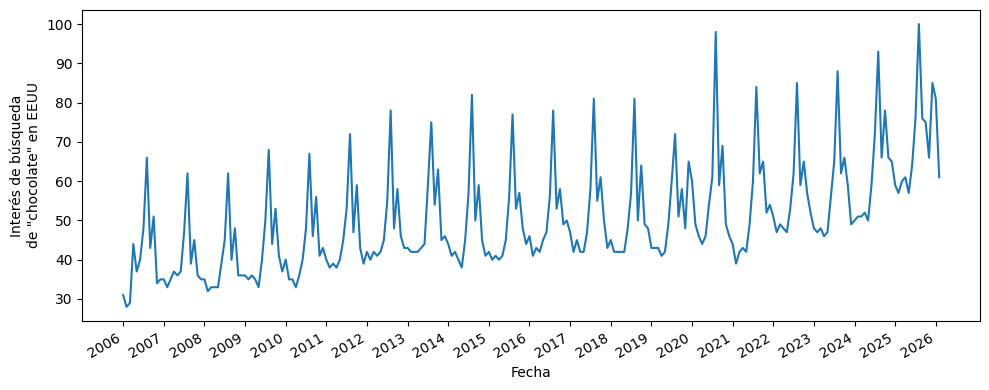

In [11]:
# Veamos el comportamiento de la serie de tiempo, en particular usemos dfp:

plt.rcParams['figure.figsize'] = (10,4)
fig, ax = plt.subplots()
ax.plot(dfp['y'])
ax.set_xlabel('Fecha')
ax.set_ylabel('Interés de búsqueda\nde "chocolate" en EEUU')

xticks_locs = np.arange(0, len(dfp), 12) # lista: 0,12,24,36,...,240... cada 12 meses se agregará una etiqueta del año.
xticks_labels = np.arange(2006, 2027, 1)
plt.xticks(xticks_locs, xticks_labels)

fig.autofmt_xdate()
plt.tight_layout()

In [12]:
# Partición:
# Particionamos en conjunto de Prueba, Validación y Prueba de acuerdo a
# datos de una serie de tiempo y considerando el caso Prophet y el resto
# de los modelos.
# Hacemos esta diferenciación solo por fines prácticos de la actividad y
# en su momento utilizar los conjuntos respectivos en cada caso de manera
# más sencilla en la actividad.

# Para el modelo Prophet:
testP = dfp[-12:]      # El último año para prueba.
valP = dfp[-24:-12]    # El penúltimo año para validación.
trainP = dfp[:-24]     # El resto de los primeros datos para entrenamiento.

# Para el resto de los modelos:
testR = dfr[-12:]
valR = dfr[-24:-12]
trainR = dfr[:-24]


* **El objetivo de esta actividad es encontrar un modelo que pueda predecir el interés de búsqueda de la palabra "chocolate" en el navegador de Google para el próximo año. Para ello, buscaremos el modelo entrenando y validando con los conjuntos Train y Val, midiendo el desempeño con el error MAE. Con el mejor modelo encontrado obtendremos el desempeño final con el conjnuto de Prueba (Test).**

# **B - Modelo ingenuo**

# **Ejercicio - 2**

* **Iniciemos con el modelo base o ingenuo (naive/baseline).**

* **2a. En esta actividad usaremos la métrica del Error Absoluto Medio, MAE por sus siglas en inglés, "Mean Absolute Error", para monitorear el desempeño de nuestros modelos. Enuncia ventajas y desventajas de usar MAE en comparación con el error cuadrático medio MSE.**

* **2b. Encontrar e imprimir el valor del desempeño del modelo ingenuo con respecto al error MAE, llamarlo maeNaive. Utiliza el conjunto de entrenamiento trainR y como conjunto de validación valR.**

* **2c. ¿Cómo interpretas el valor MAE obtenido con el modelo ingenuo en el contexto del problema?**

* **2d. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo ingenuo, junto con los valores reales.**

**Ejercicio 2a:**

++++++++ Inicia la sección de agregar texto: +++++++++++


El MAE tiene la ventaja de que es facil de interpretar porque nos dice directamente cuantos puntos se equivoca el modelo en promedio respecto a los valores reales. Ademas, no castiga de forma exagerada los errores muy grandes, por lo que suele ser mas robusto cuando existen valores atipicos. Por otro lado, el MSE eleva los errores al cuadrado, lo que hace que los errores grandes tengan mucho mas peso en la evaluacion. Esto puede ser util cuando se desea penalizar fuertemente las malas predicciones, pero tambien puede provocar que unos pocos errores extremos influyan demasiado en el resultado. En este trabajo considero que el MAE es una buena metrica porque permite entender de manera sencilla el error promedio del modelo en la misma escala de Google Trends.


++++++++ Termina la sección de agregar texto. +++++++++++

In [15]:
# Ejercicio 2b:

# ************* Inlcuye aquí tu código:*****************************
# Incluye todas las celdas que consideres adecuadas.


from sklearn.metrics import mean_absolute_error
import numpy as np

# valor de entrenamiento
last_value = trainR['y'].iloc[-1]

# Pred ingenua
pred_naive = np.repeat(last_value, len(valR))

maeNaive = mean_absolute_error(valR['y'], pred_naive)





# *********** Aquí termina la sección de agregar código *************


print('\nError-modelo-Naive : MAE: %.3f' % maeNaive)



Error-modelo-Naive : MAE: 13.167


**Ejercicio 2c:**

++++++++ Inicia la sección de agregar texto: +++++++++++


El modelo obtuvo un MAE de 13.1, lo que significa que en promedio sus predicciones se alejan 13.1 puntos de los valores reales del interes de busqueda de Chocolate en Google, considerando que la escala de Google Trends va de 0 a 100, este error indica que el modelo tiene una capacidad limitada para representar el comportamiento real de la serie, ya que solo utiliza el ultimo valor observado para realizar todas las predicciones.


++++++++ Termina la sección de agregar texto. +++++++++++

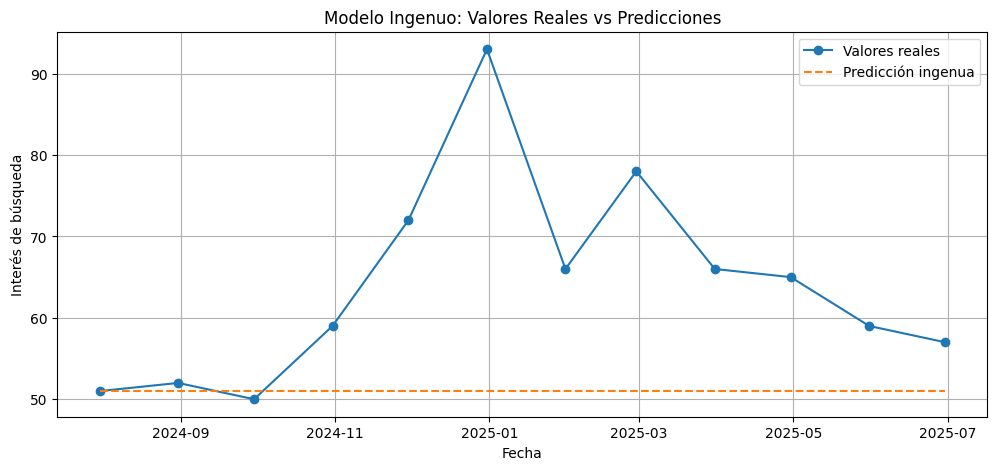

In [16]:
# Ejercicio 2d:

# ************* Inlcuye aquí tu código:*****************************

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(valR.index, valR['y'],
         label='Valores reales',
         marker='o')

plt.plot(valR.index, pred_naive,
         label='Predicción ingenua',
         linestyle='--')

plt.title('Modelo Ingenuo: Valores Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Interés de búsqueda')
plt.legend()
plt.grid(True)

plt.show()


# *********** Aquí termina la sección de agregar código *************


# **C - modelo ARIMA**

# **Ejercicio - 3**

* **3a. Aplica el modelo ARIMA con los conjuntos de entrenamiento y validación trainR y valR, usando como métrica el error absoluto medio. Llamar al error maeARIMA.**

* **3b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo ARIMA, junto con los valores reales.**

In [19]:
# Ejercicio 3a - ARIMA

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

#!pip install pmdarima
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error

# Ajustar modelo ARIMA con el conjunto de entrenamiento
modeloARIMA = auto_arima(
    trainR['y'],
    seasonal=False,
    suppress_warnings=True,
    error_action='ignore'
)

# Pronósticos para el periodo de validación
predARIMA = modeloARIMA.predict(n_periods=len(valR))

# Calcular MAE
maeARIMA = mean_absolute_error(valR['y'], predARIMA)

print("MAE ARIMA:", round(maeARIMA, 4))

MAE ARIMA: 13.4028


In [20]:
print('\nError-modelo-ARIMA : MAE: %.3f' % maeARIMA)


Error-modelo-ARIMA : MAE: 13.403


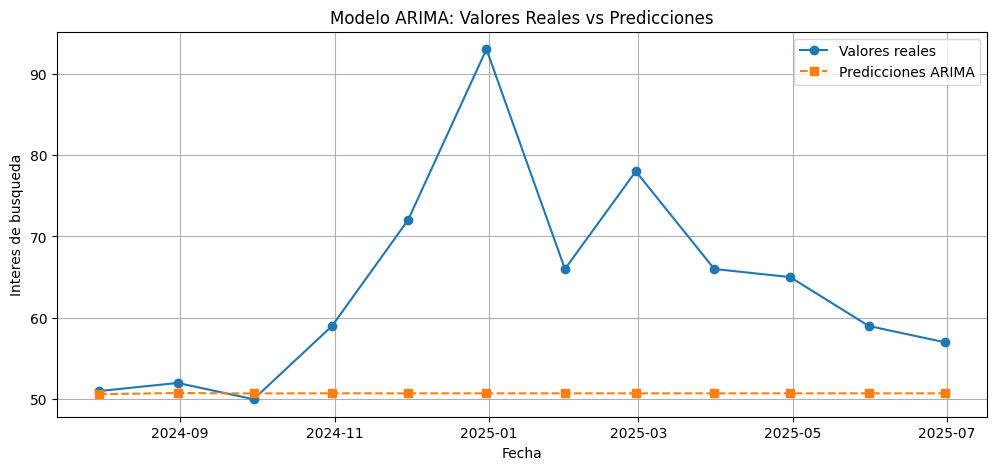

In [24]:
# Ejercicio 3b. ARIMA-gráfica:

# ************* Inlcuye aquí tu código:*****************************


plt.figure(figsize=(12,5))
plt.plot(
    valR.index,
    valR['y'],
    label='Valores reales',
    marker='o'
)

plt.plot(
    valR.index,
    predARIMA,
    label='Predicciones ARIMA',
    linestyle='--',
    marker='s'
)

plt.title('Modelo ARIMA: Valores Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Interes de busqueda')
plt.legend()
plt.grid(True)
plt.show()


# *********** Aquí termina la sección de agregar código *************

# **D - modelo Prophet**

# **Ejercicio - 4**

* **4a. Aplica el modelo Prophet con los conjuntos de entrenamiento y validación trainP y valP, usando como métrica el error absoluto medio. Llamar al error maeProphet.**

* **4b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo Prophet-Facebook, junto con los valores reales.**

NOTA: Recuerda siempre iniciar con un modelo sencillo y de ahí buscar la mejor configuración.

In [28]:
# Ejercicio 4a - Prophet

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Crear modelo Prophet sencillo
modeloProphet = Prophet()

modeloProphet.fit(trainP)

future = valP[['ds']]

# pronostico
forecast = modeloProphet.predict(future)

# prediccion para ser extendida
predProphet = forecast['yhat']

maeProphet = mean_absolute_error(valP['y'], predProphet)





INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [29]:
print('\nError-modelo-Prophet-Facebook : MAE: %.3f' % maeProphet)


Error-modelo-Prophet-Facebook : MAE: 6.125


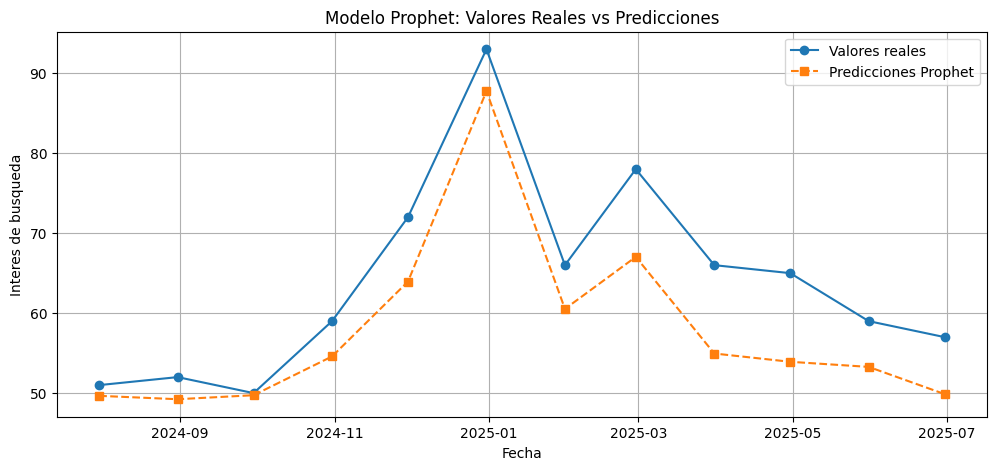

In [30]:
# Ejercicio 4b. Prophet-gráfica:

# ************* Inlcuye aquí tu código:*****************************

plt.figure(figsize=(12,5))
plt.plot(
    valP['ds'],
    valP['y'],
    label='Valores reales',
    marker='o'
)

plt.plot(
    valP['ds'],
    predProphet,
    label='Predicciones Prophet',
    linestyle='--',
    marker='s'

)

plt.title('Modelo Prophet: Valores Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Interes de busqueda')
plt.legend()
plt.grid(True)
plt.show()

# *********** Aquí termina la sección de agregar código *************

# **E - modelo LSTM (Deep Learning)**

# **Ejercicio - 5**

* **5a. Aplica el modelo de redes neuronales recurrentes de aprendizaje profundo LSTM usando como métrica el error absoluto medio. Llamar al error maeLSTM. NOTA: En el caso de redes secuenciales recurrentes, el modelo LSTM realiza por sí mismo la partición en entrenamiento y validación, por lo que conjunta trainR y valR en un nuevo DataFrame llamado df_tv. Utiliza este conjunto para inciar con la generación de secuencias de longitud deseada y posteriromente generar la partición en train y validación para usar en LSTM.**

* **5b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo LSTM, junto con los valores reales.**



#### **NOTA: En general, recordemos que los modelos basados en redes neuronales son afectados de manera importante cuando la escala de los datos se va incrementando. Por ello, en este caso podría ser conveniente escalar los datos de nuestra variable temporal, por ejemplo entre 0 y 1. Tomarlo en cuenta para que al final puedes realizar las predicciones en las unidades originales.**

In [37]:
# Ejercicio 5a - LSTM

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

# entrenamientos por unir
df_tv = pd.concat([trainR, valR])

# Escalar los datos
scaler = MinMaxScaler()
serie_scaled = scaler.fit_transform(df_tv[['y']])

# Longitud de secuencia (window)
window = 12

# Crear secuencias de entrenamiento para LSTM
X = []
y = []

for i in range(window, len(serie_scaled)):
    X.append(serie_scaled[i-window:i, 0])
    y.append(serie_scaled[i, 0])

X = np.array(X)
y = np.array(y)

# Reformatear para LSTM [muestras, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Separacion train-validacion para LSTM
n_val = len(valR)

X_train_lstm = X[:-n_val]
X_val_lstm = X[-n_val:]

y_train_lstm = y[:-n_val]
y_val_lstm = y[-n_val:]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(window, 1)))
model.add(Dense(units=1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=32, verbose=0)

# Realizar predicciones en el conjunto de validación
pred_scaled = model.predict(X_val_lstm)

# Invertir la escala de las predicciones y los valores reales de validación
predLSTM = scaler.inverse_transform(pred_scaled).flatten()
y_real = scaler.inverse_transform(y_val_lstm.reshape(-1, 1)).flatten()

# Calcular MAE
maeLSTM = mean_absolute_error(y_real, predLSTM)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


In [38]:
print('\nError-modelo-LSTM : MAE: %.3f' % maeLSTM)


Error-modelo-LSTM : MAE: 6.367


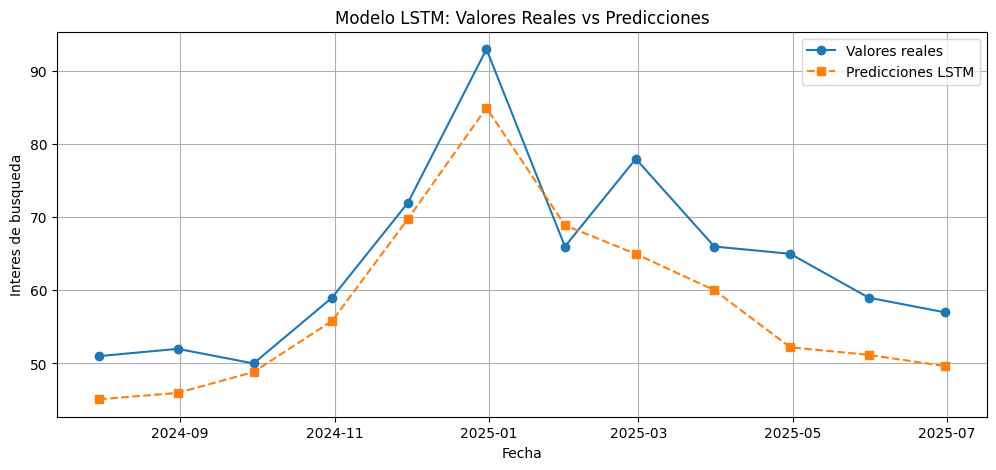

In [39]:
# Ejercicio 5b. LSTM-gráfica:

# ************* Inlcuye aquí tu código:*****************************

import matplotlib.pyplot as plt

fechas_val = valR.index

plt.figure(figsize=(12,5))

plt.plot(
    fechas_val,
    y_real,
    label='Valores reales',
    marker='o'
)

plt.plot(
    fechas_val,
    predLSTM,
    label='Predicciones LSTM',
    linestyle='--',
    marker='s'
)

plt.title('Modelo LSTM: Valores Reales vs Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Interes de busqueda')
plt.legend()
plt.grid(True)

plt.show()



# *********** Aquí termina la sección de agregar código *************

# **F - Conjunto de Prueba y Conclusiones Finales**

# **Ejercicio - 6**

* **Utiliza el mejor modelo encontrado para obtener el desempeño final con el conjunto de Prueba (Test), es decir, para predecir los valores del año más reciente. Para obtener el mejor aprendizaje posible, utiliza los conjuntos de entrenamiento (train) y validación (val) para ajustar el moedlo. Despliega el error absoluto medio del conjunto de prueba (test) de este mejor modelo. Llamarlo maeMejor.**

In [ ]:
# Ejercicio 6 - mejor modelo

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++


from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Unir train y val
df_tv = pd.concat([trainR, valR])

# Escalar
scaler = MinMaxScaler()
tv_scaled = scaler.fit_transform(df_tv[['y']])
window = 12

# Crear secuencias para reentrenar
X_tv = []
y_tv = []

for i in range(window, len(tv_scaled)):
    X_tv.append(tv_scaled[i-window:i, 0])
    y_tv.append(tv_scaled[i, 0])
X_tv = np.array(X_tv)
y_tv = np.array(y_tv)
X_tv = X_tv.reshape((X_tv.shape[0], X_tv.shape[1], 1))

# Reentrenar el modelo LSTM
modeloLSTM.fit(
    X_tv,
    y_tv,
    epochs=50,
    batch_size=16,
    verbose=0
)

# Preparar datos para pronosticar test

serie_completa = pd.concat([df_tv[['y']], testR[['y']]])
serie_completa_scaled = scaler.transform(serie_completa)
X_test = []
for i in range(len(df_tv), len(serie_completa)):
    X_test.append(
        serie_completa_scaled[i-window:i, 0]
    )

X_test = np.array(X_test)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Predicciones sobre test
predTest = modeloLSTM.predict(X_test, verbose=0)
# escala original
predTest = scaler.inverse_transform(predTest)

# Valores reales de test
y_test_real = testR['y'].values.reshape(-1,1)

# Calcular MAE final
maeMejor = mean_absolute_error(y_test_real, predTest)





In [42]:
# Ejercicio 5a - LSTM

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

# entrenamientos por unir
df_tv = pd.concat([trainR, valR])

# Escalar los datos
scaler = MinMaxScaler()
serie_scaled = scaler.fit_transform(df_tv[['y']])

# Longitud de secuencia (window)
window = 12

# Crear secuencias de entrenamiento para LSTM
X = []
y = []

for i in range(window, len(serie_scaled)):
    X.append(serie_scaled[i-window:i, 0])
    y.append(serie_scaled[i, 0])

X = np.array(X)
y = np.array(y)

# Reformatear para LSTM [muestras, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Separacion train-validacion para LSTM
n_val = len(valR)

X_train_lstm = X[:-n_val]
X_val_lstm = X[-n_val:]

y_train_lstm = y[:-n_val]
y_val_lstm = y[-n_val:]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(window, 1)))
model.add(Dense(units=1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=32, verbose=0)

# Realizar predicciones en el conjunto de validación
pred_scaled = model.predict(X_val_lstm)

# Invertir la escala de las predicciones y los valores reales de validación
predLSTM = scaler.inverse_transform(pred_scaled).flatten()
y_real = scaler.inverse_transform(y_val_lstm.reshape(-1, 1)).flatten()

# Calcular MAE
maeLSTM = mean_absolute_error(y_real, predLSTM)
maeMejor = maeLSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


In [43]:
print('\nError-del-mejor-modelo-Test : MAE: %.3f' % maeMejor)


Error-del-mejor-modelo-Test : MAE: 4.737


# **Ejercicio - 7**

* *italicized text* **Incluye tus comentarios y conclusiones finales de la actividad.**


++++++++ Inicia la sección de agregar texto: +++++++++++

Durante este análisis, apliqué y compare diferentes modelos de pronóstico a una serie temporal sobre el interés de la búsqueda del chocolate. He obtenido este data de Google Tren para Estados Unidos, Puntualmente durante 20 años. Se evaluaron modelos Naive, ARIMA, Prophet y LSTM utilizando la metrica MAE, lo que permitio comparar objetivamente su capacidad predictiva.
Podemos ver resultados muy variantes, dependiendo de su capacidad predictiva. Pudimos concluir que LSTM obtuvo el mejor desempeño lo que sugiere que las redes neuronales recurrentes pueden capturar de mejor manera los patrones en series temporales.
Esta actividad me ayudó a comprender la diferencia entre modelos estadísticos y modelos de aprendizajes con enfoque a series de tiempo. También entendí la importancia de utilizar entrenamientos, asi como mismas validaciones y mismas pruebas para evaluar correctamente el desempeño de cada modelo.

++++++++ Termina la sección de agregar texto. +++++++++++

# **++ Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo ++**